In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pickle, h5py, os, glob
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_probability as tfp
import jax.numpy as jnp
import matplotlib.pyplot as plt
from tqdm import tqdm

from sobol_seq import i4_sobol

# preprocessing
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# inference
from msi.gaussian_mixture.gaussian_mixture_model import ConditionalGMM
from msi.gaussian_likelihood.dense_emulator import DenseEmulator

from pzflow import Flow
from pzflow.bijectors import ShiftBounds, RollingSplineCoupling, Chain
from pzflow.distributions import CentBeta13
from sklearn.model_selection import train_test_split

# utils
from msi.utils import input_output, plotting, mcmc
from msfm.utils import prior, parameters, files, power_spectra

23-10-06 00:19:43   imports.py INF   Setting up healpy to run on 32 CPUs 
23-10-06 00:19:44   imports.py INF   Setting up healpy to run on 32 CPUs 


In [3]:
out_dir = "/pscratch/sd/a/athomsen/run_files/v5/power_spectra"
all_params = ["Om", "s8", "Ob", "H0", "ns", "w0", "Aia", "n_Aia", "bg", "n_bg", "bg2", "n_bg2"]

# data loading

## Arne version

In [31]:
# v4
# cl_fidu_file = "/pscratch/sd/a/athomsen/DESY3/v4/large_scales/cls/fiducial_cls.h5"
# cl_grid_file = "/pscratch/sd/a/athomsen/DESY3/v4/large_scales/cls/grid_cls.h5"

# v5
cl_base = "/pscratch/sd/a/athomsen/DESY3/v5/linear_bias/cls"
conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v5/linear_bias.yaml")
run_label = "linear_bias"

# cl_base = "/pscratch/sd/a/athomsen/DESY3/v5/quadratic_bias/cls"
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v5/quadratic_bias.yaml")
# run_label = "quadratic_bias"

# cl_base = "/pscratch/sd/a/athomsen/DESY3/v5/quadratic_bias_v2/cls"
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v5/quadratic_bias.yaml")
# run_label = "quadratic_bias_v2"

# cl_base = "/pscratch/sd/a/athomsen/DESY3/v5/stochasticity/cls"
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v5/stochasticity.yaml")
# run_label = "stochasticity"

cl_fidu_file = os.path.join(cl_base, "fiducial_cls.h5")
cl_grid_file = os.path.join(cl_base, "grid_cls.h5")

In [32]:
with h5py.File(cl_fidu_file, "r") as f:
    fidu_cls = f["cls"][:]
    
    fidu_i_example = f["i_example"][:]
    fidu_i_noise = f["i_noise"][:]
        
with h5py.File(cl_grid_file, "r") as f:
    grid_cls = f["cls"][:]
    grid_theta = f["cosmo"][:]
    
    grid_i_sobol = f["i_sobol"][:]
    grid_i_example = f["i_example"][:]
    grid_i_noise = f["i_noise"][:]
        
print("\noriginal shapes")
print(fidu_cls.shape)
print(grid_cls.shape)
print(grid_theta.shape)

# throw away some scales
# fidu_cls = fidu_cls[:,:24,:]
# grid_cls = grid_cls[:,:,:24,:]


original shapes
(2400, 32, 36)
(2500, 48, 32, 36)
(2500, 10)


### lensing only

In [33]:
# bin_indices = power_spectra.get_cl_bin_indices(with_lensing=True, with_clustering=False, with_cross_z=True, with_cross_probe=False)
# params = ["Om", "s8", "Aia", "n_Aia"]
# probe_label = "lensing"

### clustering only

In [34]:
bin_indices, bin_names = power_spectra.get_cl_bin_indices(with_lensing=False, with_clustering=True, with_cross_z=True, with_cross_probe=False)
# params = ["Om", "s8", "bg", "n_bg", "bg2",  "n_bg2"]
params = ["Om", "s8", "bg", "n_bg"]
probe_label = "clustering"

### added probes

In [35]:
# bin_indices = power_spectra.get_cl_bin_indices(with_lensing=True, with_clustering=True, with_cross_z=True, with_cross_probe=False)
# params = ["Om", "s8", "Aia", "n_Aia", "bg", "n_bg", "bg2",  "n_bg2"]
# # params = ["Om", "s8", "Aia", "n_Aia", "bg", "n_bg"]
# probe_label = "combined_added"

### cross probes

In [36]:
# bin_indices = power_spectra.get_cl_bin_indices(with_lensing=True, with_clustering=True, with_cross_z=True, with_cross_probe=True)
# params = ["Om", "s8", "Aia", "n_Aia", "bg", "n_bg", "bg2",  "n_bg2"]
# # params = ["Om", "s8", "Aia", "n_Aia", "bg", "n_bg"]
# probe_label = "combined_cross"

In [37]:
# select the right auto and cross bins
print(f"Using the bin indices {bin_indices}")
print(f"With names {bin_names}")
fidu_cls = fidu_cls[...,bin_indices]
grid_cls = grid_cls[...,bin_indices]

# select the right cosmological parameters
param_indices = []
for i, param in enumerate(all_params):
    if param in params:
        param_indices.append(i)
grid_theta = grid_theta[...,param_indices]

print("\nselected shapes")
print(fidu_cls.shape)
print(grid_cls.shape)
print(grid_theta.shape)

# concatenate the bins along the last axis
fidu_cls = np.concatenate([fidu_cls[...,i] for i in range(fidu_cls.shape[-1])], axis=-1)
grid_cls = np.concatenate([grid_cls[...,i] for i in range(grid_cls.shape[-1])], axis=-1)

# concatenate the examples along the first axis
grid_theta = np.repeat(grid_theta, repeats=grid_cls.shape[1], axis=0)
grid_cls = np.concatenate([grid_cls[i,...] for i in range(grid_cls.shape[0])], axis=0)

print("\nconcatenated shapes")
print(fidu_cls.shape)
print(grid_cls.shape)
print(grid_theta.shape)

Using the bin indices [26, 27, 28, 29, 30, 31, 32, 33, 34, 35]
With names ['bin_4x4' 'bin_4x5' 'bin_4x6' 'bin_4x7' 'bin_5x5' 'bin_5x6' 'bin_5x7'
 'bin_6x6' 'bin_6x7' 'bin_7x7']

selected shapes
(2400, 32, 10)
(2500, 48, 32, 10)
(2500, 4)

concatenated shapes
(2400, 320)
(120000, 320)
(120000, 4)


## Virginia version

In [11]:
# with h5py.File("/global/homes/a/athomsen/multiprobe-simulation-forward-model/data/CosmoGridV1_metainfo.h5", "r") as f:
#     cosmogrid_info = f["parameters/grid"][:]
# info_Om = cosmogrid_info["Om"]


### clustering only

In [12]:
# params = ["Om", "s8", "bg", "n_bg"]
# probe_label = "clustering"

# clustering_file = "/global/cfs/cdirs/des/athomsen/power_spectra/v3/cls_clustering.h5"

# with h5py.File(clustering_file, "r") as f:
#     bin_lengths = f["bin_lengths"][:]
    
#     fidu_index = f["fidu/index"][:]
#     fidu_cls = f["fidu/cls"][:]
    
#     grid_theta = f["grid/theta"][:]
#     grid_cls = f["grid/cls"][:]
    
# # only select the right parameters
# grid_theta = grid_theta[:,[0, 1, 8, 9]]

### lensing only

In [13]:
# params = ["Om", "s8", "Aia", "n_Aia"]
# probe_label = "lensing"

# # lensing_file = "/global/cfs/cdirs/des/athomsen/power_spectra/v3/cls_lensing.h5"
# lensing_file = "/global/cfs/cdirs/des/vajani/combined-probes/output_repo/summaries/weak_lensing/v4/cls_lensing_large_scales.h5"

# with h5py.File(lensing_file, "r") as f:
#     bin_lengths = f["bin_lengths"][:]

#     fidu_index = f["fidu/index"][:]
#     fidu_cls = f["fidu/cls"][:]
    
#     grid_theta = f["grid/theta"][:]
#     grid_cls = f["grid/cls"][:]

## general

In [38]:
n_params = len(params)

# print(f"fidu_index.shape = {fidu_index.shape}")
# print(f"fidu_cls.shape = {fidu_cls.shape}\n")

# print(f"grid_theta.shape = {grid_theta.shape}")
# print(f"grid_cls.shape = {grid_cls.shape}")

# # assert fidu_index.shape[0] == fidu_cls.shape[0]
# assert grid_theta.shape[0] == grid_cls.shape[0]
# assert grid_cls.shape[-1] == fidu_cls.shape[-1]

### plot power spectra

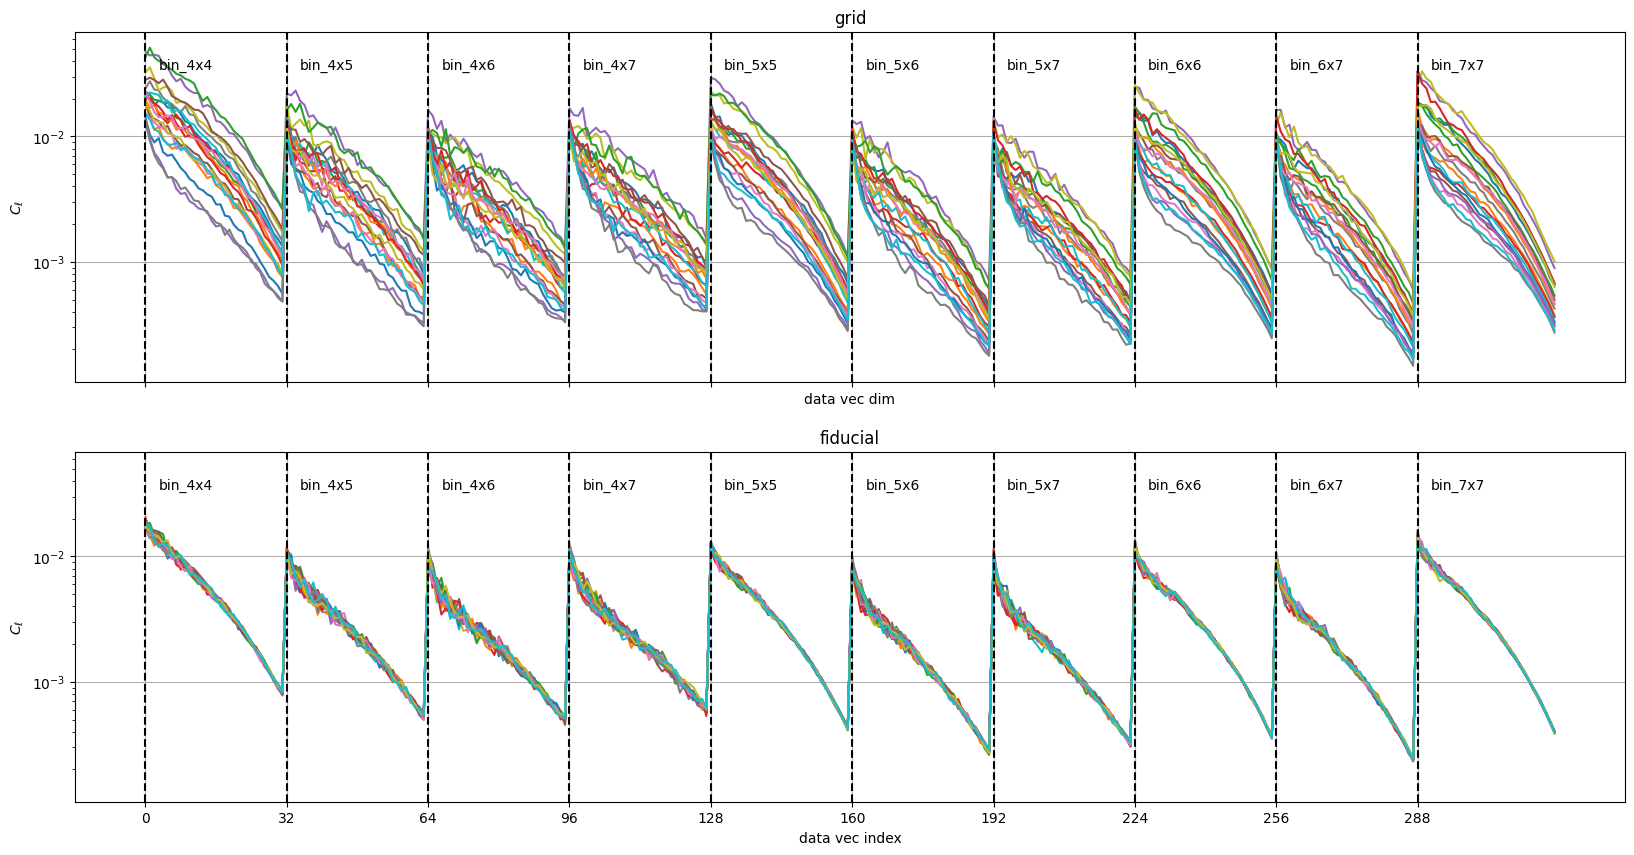

In [39]:
# grid
random_indices = np.random.choice(np.arange(grid_cls.shape[0]), 20)

fig, ax = plt.subplots(figsize=(20,10), nrows=2, sharex=True, sharey=True)

for i in random_indices:    
    ax[0].plot(grid_cls[i])
        
ax[0].set(xscale="linear", yscale="log", title=r"grid", xlabel="data vec dim", ylabel=r"$C_\ell$")
ax[0].grid(True)

# fiducial
random_indices = np.random.choice(np.arange(fidu_cls.shape[0]), 20)

for i in random_indices:    
    ax[1].plot(fidu_cls[i])

ax[1].set(title=r"fiducial", xlabel="data vec index", ylabel=r"$C_\ell$")
ax[1].grid(True)

# cosmetics
bin_size = 32

x = 0
ticks = []
for i, x in enumerate(np.arange(0, len(bin_names)*bin_size, bin_size)):
    ax[0].axvline(x, color="k", linestyle="--")
    ax[1].axvline(x, color="k", linestyle="--")
        
    # ax[0].text(x + 3, 0.05*ax[0].get_ylim()[1], bin_labels[i])
    # ax[1].text(x + 3, 0.05*ax[1].get_ylim()[1], bin_labels[i])

    ax[0].text(x + 3, ax[0].get_ylim()[1] - 0.5 * ax[0].get_ylim()[1], bin_names[i])
    ax[1].text(x + 3, ax[0].get_ylim()[1] - 0.5 * ax[0].get_ylim()[1], bin_names[i])

    ticks.append(x)
    
ax[0].set_xticks(ticks)
ax[1].set_xticks(ticks)

fig.savefig(f"plots/raw_cls_{probe_label}_{run_label}.png", bbox_inches="tight", dpi=100)    

In [16]:
fidu_cov = np.cov(fidu_cls, rowvar=False)
fidu_corr = np.corrcoef(fidu_cls, rowvar=False)

### observation

In [17]:
# i_median = np.argmin(np.sum(np.square(np.median(fidu_cls, axis=0, keepdims=True) - fidu_cls), axis=-1))
# print(f"The example index closest to the median is {i_median}")

# i_median = 745
# i_median = 1227
i_median = 0
obs_cls = fidu_cls[np.newaxis, i_median]

# obs_cls = np.median(fidu_cls, axis=0, keepdims=True)
# obs_cls = fidu_cls[0,:][np.newaxis]

# obs_cls = grid_cls[0,:][np.newaxis]

print(obs_cls.shape)
obs_label = f"fidu_{i_median}"

(1, 320)


### preprocessing

In [18]:
# # StandardScaler
# scaler = StandardScaler()

# grid_standard_cls = scaler.fit_transform(grid_cls)
# fidu_standard_cls = scaler.transform(fidu_cls)
# obs_standard_cls = scaler.transform(obs_cls)

# # PCA
# pca = PCA(n_components=10)

# grid_compressed_cls = pca.fit_transform(grid_standard_cls)
# fidu_compressed_cls = pca.transform(fidu_standard_cls)
# obs_compressed_cls = pca.transform(obs_standard_cls)

# print(f"total explained variance = {np.sum(pca.explained_variance_ratio_)}")
# print(f"grid shape before compression: {grid_cls.shape}")
# print(f"grid shape after compression: {grid_compressed_cls.shape}")

# # # StandardScaler
# # scaler = StandardScaler()

# # grid_compressed_cls = scaler.fit_transform(grid_compressed_cls)
# # fidu_compressed_cls = scaler.transform(fidu_compressed_cls)
# # obs_compressed_cls = scaler.transform(obs_compressed_cls)

In [19]:
# logarithm and standardization
scaler = StandardScaler()

grid_compressed_cls = scaler.fit_transform(np.log(grid_cls))
fidu_compressed_cls = scaler.transform(np.log(fidu_cls))
obs_compressed_cls = scaler.transform(np.log(obs_cls))

# PCA, is whitening a good idea?
pca = PCA(n_components=10, whiten=True)

grid_compressed_cls = pca.fit_transform(grid_compressed_cls)
fidu_compressed_cls = pca.transform(fidu_compressed_cls)
obs_compressed_cls = pca.transform(obs_compressed_cls)

print(f"total explained variance = {np.sum(pca.explained_variance_ratio_)}")
print(f"grid shape before compression: {grid_cls.shape}")
print(f"grid shape after compression: {grid_compressed_cls.shape}")

total explained variance = 0.940873898344123
grid shape before compression: (120000, 320)
grid shape after compression: (120000, 10)


# inference with normalizing flow

In [20]:
# flow_data = grid_compressed_cls
# flow_conds = grid_theta
# flow_obs = obs_compressed_cls

In [21]:
# n_examples = flow_data.shape[0]
# n_summaries = flow_data.shape[1]
# summary_labels = [f"summary_{i}" for i in range(n_summaries)]

# # build data frame
# df_total = pd.DataFrame()

# for i, summary_label in enumerate(summary_labels):
#     df_total[summary_label] = flow_data[:,i]
    
# for i, param in enumerate(params):
#     df_total[param] = flow_conds[:,i]
    
# df_train, df_val = train_test_split(df_total, test_size=0.1)

# # repack the observation
# obs_df = pd.DataFrame([flow_obs[0]], columns=summary_labels)

In [22]:
# latent = CentBeta13(input_dim=n_summaries, B=5)
# bijector = Chain(
#     ShiftBounds(jnp.array(df_total[summary_labels].min(axis=0)), jnp.array(df_total[summary_labels].max(axis=0)), B=4),
#     RollingSplineCoupling(n_summaries, B=5, n_conditions=n_params, hidden_dim=128),
# )

# flow = Flow(
#     data_columns=summary_labels, 
#     conditional_columns=params, 
#     latent=latent,
#     bijector=bijector,
# )

# # train
# loss_train, loss_val = flow.train(df_train, df_val, verbose=True, epochs=100)

# # plot
# fig, ax = plt.subplots()
# ax.plot(loss_train, label="training set")
# ax.plot(loss_val, label="validation set")
# ax.set(xlabel="epoch", ylabel="loss")
# ax.legend()
# ax.grid(True)

In [23]:
# method_label = f"flow_like"
# label = "cls_" + probe_label + "_" + method_label# + "_auto"

# def log_likelihood(X): 
#     # convert to dataframe
#     X = pd.DataFrame(X, columns=params)
#     X = X.join(obs_df, how="cross")

#     # evaluate the normalizing flow
#     log_prob = flow.log_prob(X)
    
#     # enforce the prior
#     log_prob = prior.log_posterior(X.loc[:,params], log_prob, params=params, conf=None)

#     return log_prob

# chain = mcmc.run_emcee(
#     log_likelihood,
#     params,
#     out_dir=out_dir,
#     label=label,
#     n_steps=1000,
# )

# plotting.plot_chains(
#     chain, 
#     params, 
#     out_dir=out_dir, 
#     labels=label,
# )

# inference with mixture of Gaussians

In [24]:
x_gauss_mix = grid_theta

y_gauss_mix = grid_compressed_cls
obs_gauss_mix = obs_compressed_cls

23-10-06 00:19:52 gaussian_mix INF   Created GMM model with n_params = 398088 
Model: "gaussian_mixture_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gaussian_noise (GaussianNoi  (None, 4)                0         
 se)                                                             
                                                                 
 dense (Dense)               (None, 256)               1280      
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 256)               65792     
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                                 
 dense_2 (Dense)             (N

epoch:  29%|██▊       | 286/1000 [00:21<00:44, 16.03it/s, loss=-17.7, val_loss=-15.9, lr=0.000237]

Restoring model weights from the end of the best epoch: 187.


epoch:  29%|██▊       | 287/1000 [00:21<00:44, 15.94it/s, loss=-17.7, val_loss=-16.1, lr=0.000237]

Epoch 287: early stopping


epoch:  29%|██▊       | 287/1000 [00:21<00:53, 13.43it/s, loss=-17.7, val_loss=-16.1, lr=0.000237]

23-10-06 00:20:13 gaussian_mix INF   Finished training 


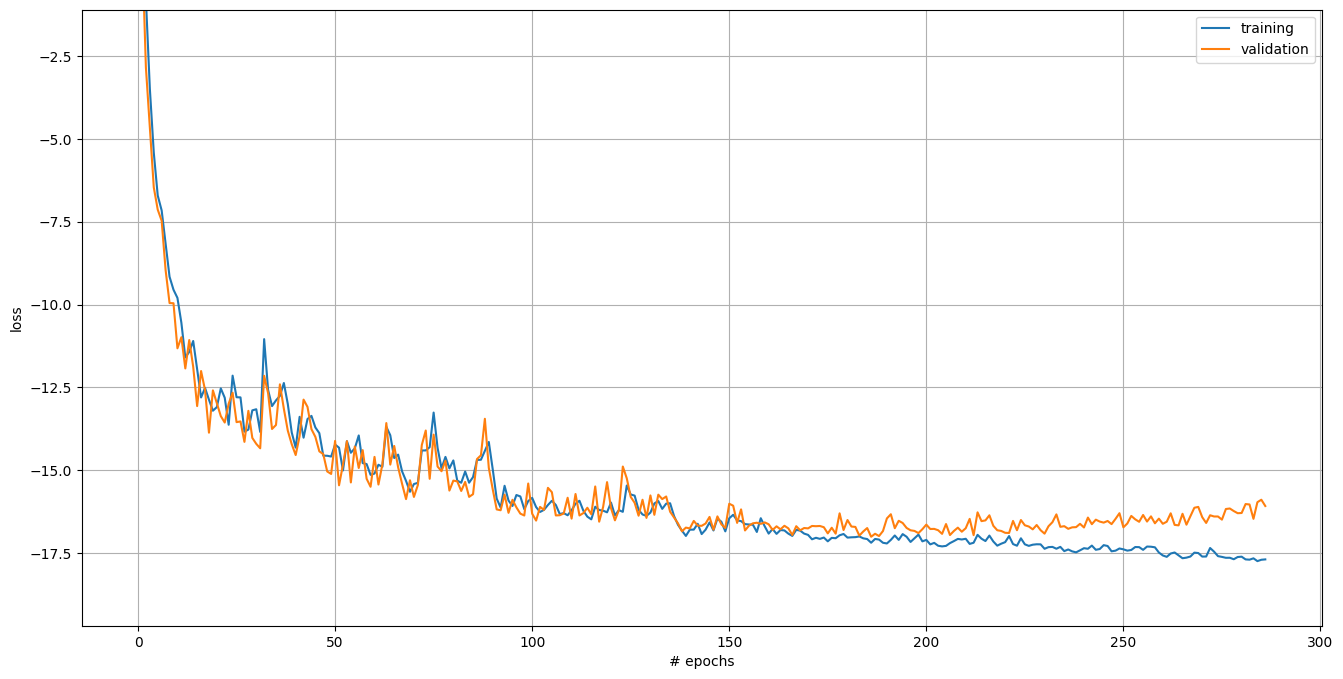

In [25]:
# p(y | x) <=> p(cls | theta)
model = ConditionalGMM(
    # theta
    x_dim=x_gauss_mix.shape[1],
    # cls
    y_dim=y_gauss_mix.shape[1],
    out_dir=None,
    n_gaussians=4,
    u_units=256,
    n_layers=5,
    activation="relu",
    input_noise_sig=0.0,
    tune_hyperparams=False,
)

# training
fit_history = model.fit(
    x=x_gauss_mix,
    y=y_gauss_mix,
    epochs=1000,
    batch_size=10000,
    early_stopping_callback=True,
    learning_rate_callback=True,
)

# plot
train_loss = fit_history.history["loss"]
vali_loss = fit_history.history["val_loss"]

fig, ax = plt.subplots(figsize=(16,8))

ax.plot(train_loss, label="training")
ax.plot(vali_loss, label="validation")

ax.legend()
ax.set(xlabel="# epochs", ylabel="loss", yscale="linear", ylim=(np.quantile(train_loss, 0.01) - 2, np.quantile(train_loss, 0.99) + 2))
ax.grid(True)

23-10-06 00:20:13      mcmc.py INF   Initial values in prior: True 


100%|██████████| 1000/1000 [01:51<00:00,  8.94it/s]


  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

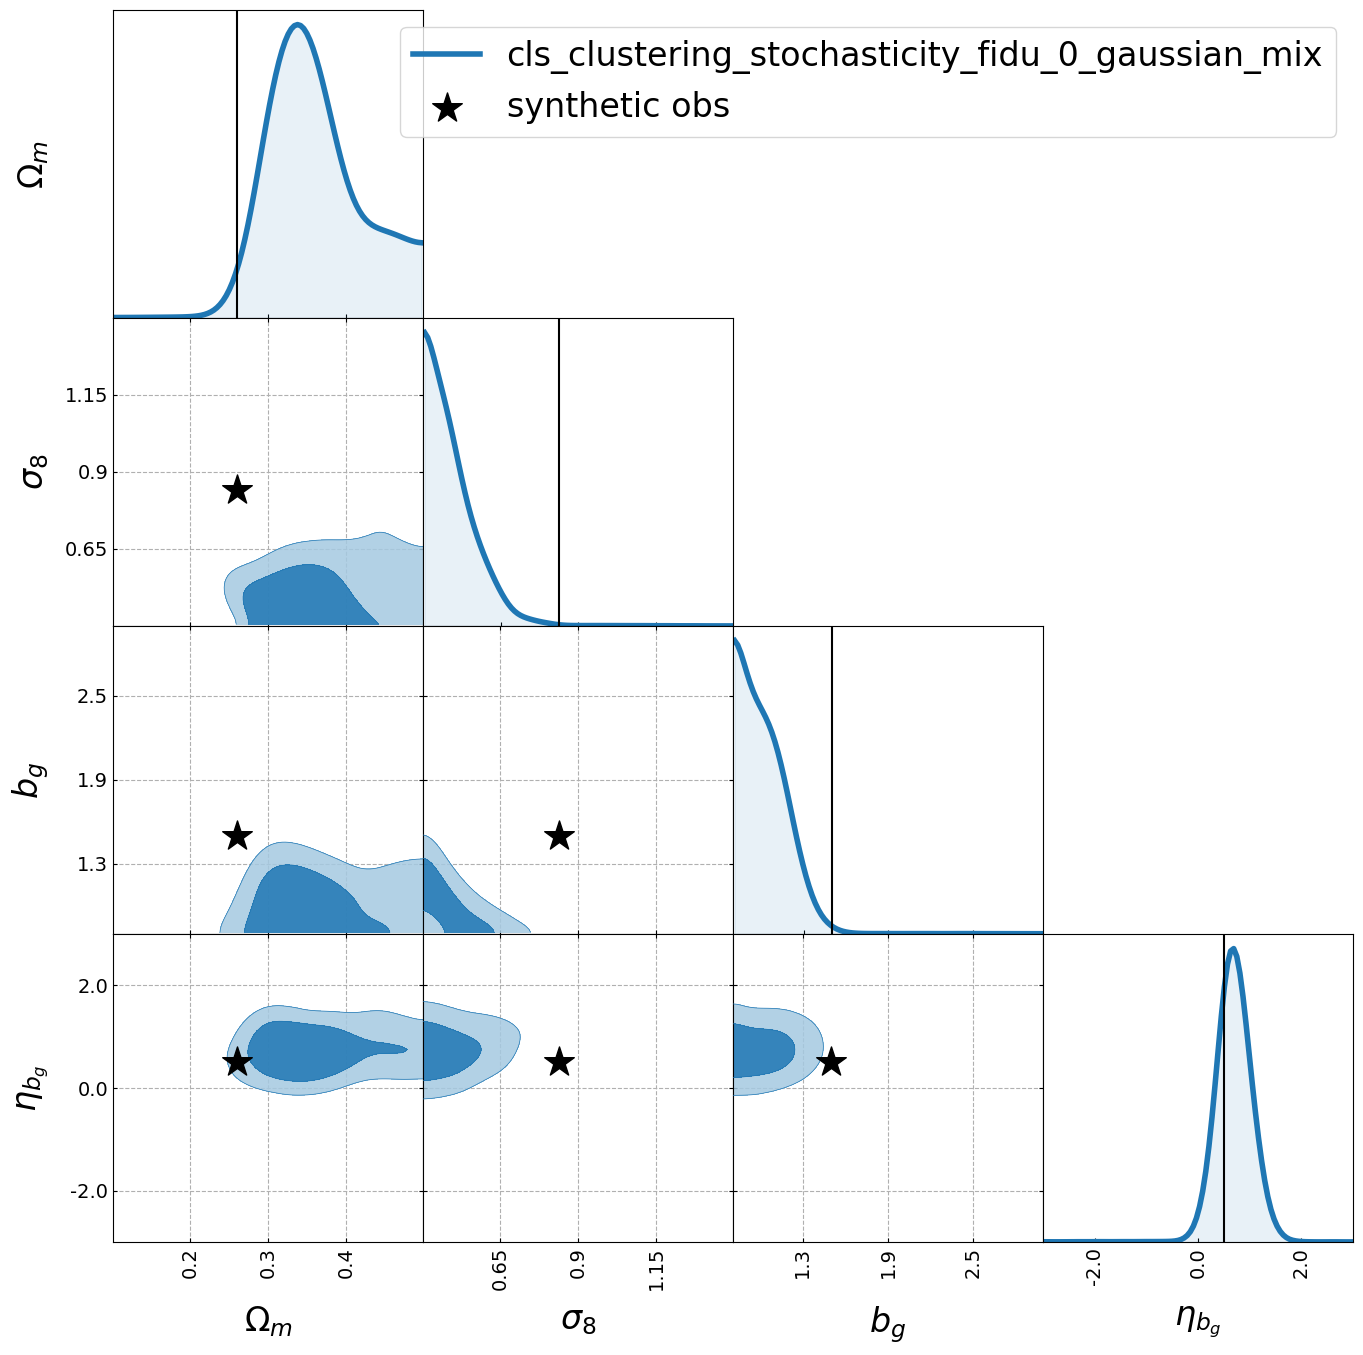

In [26]:
method_label = f"gaussian_mix"
label = "cls_" + probe_label + "_" + run_label + "_" + obs_label + "_" + method_label
# label = "cls_" + probe_label + "_" + method_label

tf_pred = tf.cast(obs_gauss_mix, dtype=tf.float64)
# tf_pred = tf.cast(obs_cls[np.newaxis,:], dtype=tf.float32)

def log_likelihood(X): 
    # evaluate the normal distribution
    log_prob = model.log_likelihood(X, tf_pred)
    
    # enforce the prior
    log_prob = prior.log_posterior(X, log_prob, params=params, conf=conf)
    
    return log_prob

chain = mcmc.run_emcee(
    log_likelihood,
    params,
    out_dir=out_dir,
    label=label,
    n_steps=1000,
)

plotting.plot_chains(
    chain, 
    params, 
    conf=conf,
    out_dir=out_dir, 
    labels=label,
)

# inference with Gaussian likelihood

In [27]:
# method_label = f"gaussian_likelihood"
# label = "cls_" + probe_label + "_" + method_label

# fidu_cov = np.cov(fidu_cls, rowvar=False)
# fidu_corr = np.corrcoef(fidu_cls, rowvar=False)

# # standardized
# fidu_standard_cov = np.cov(fidu_standard_cls, rowvar=False)
# fidu_standard_corr = np.corrcoef(fidu_standard_cls, rowvar=False)

# # compressed
# fidu_compressed_cov = np.cov(fidu_compressed_cls, rowvar=False)
# fidu_compressed_corr = np.corrcoef(fidu_compressed_cls, rowvar=False)

# # plot
# fig, ax = plt.subplots(figsize=(14,16), ncols=2, nrows=2)

# # uncompressed

# # covariance
# im = ax[0,0].pcolormesh(fidu_cov)
# ax[0,0].set(title="covariance", ylabel="uncompressed")
# ax[0,0].set_aspect("equal")

# fig.colorbar(im, ax=ax[0,0], orientation="horizontal", shrink=0.7, pad=0.1, aspect=10)

# # correlation
# im = ax[0,1].pcolormesh(fidu_corr)
# ax[0,1].set(title="correlation")
# ax[0,1].set_aspect("equal")

# fig.colorbar(im, ax=ax[0,1], orientation="horizontal", shrink=0.7, pad=0.1, aspect=10)

# # compressed

# # covariance
# im = ax[1,0].pcolormesh(fidu_compressed_cov)
# ax[1,0].set(title="covariance", ylabel="compressed")
# ax[1,0].set_aspect("equal")

# fig.colorbar(im, ax=ax[1,0], orientation="horizontal", shrink=0.7, pad=0.1, aspect=10)

# # correlation
# im = ax[1,1].pcolormesh(fidu_compressed_corr)
# ax[1,1].set(title="correlation")
# ax[1,1].set_aspect("equal")

# fig.colorbar(im, ax=ax[1,1], orientation="horizontal", shrink=0.7, pad=0.1, aspect=10)

In [28]:
# x_gauss_like = grid_theta

# y_gauss_like = grid_standard_cls
# cov_gauss_like = fidu_standard_cov
# obs_gauss_like = obs_standard_cls

In [29]:
# # f(x) = y
# emu = DenseEmulator(
#     x=tf.cast(x_gauss_like, dtype=tf.float32), 
#     y=tf.cast(y_gauss_like, dtype=tf.float32),
#     n_units=1024, 
#     n_layers=5, 
#     dropout_rate=0.0,
#     learning_rate=1e-5,
# )

# # training
# history = emu.fit(
#     x=tf.cast(x_gauss_like, dtype=tf.float32), 
#     y=tf.cast(y_gauss_like, dtype=tf.float32),
#     validation_split=0.2, 
#     batch_size=2499,
#     epochs=1000,
#     early_stopping_callback=True,
#     learning_rate_callback=True,
# )

# # plot
# fig, ax = plt.subplots(figsize=(16,8))

# ax.plot(history.history["loss"], label="training")
# ax.plot(history.history["val_loss"], label="validation")

# ax.legend()
# ax.set(xlabel="# epochs", ylabel="loss", yscale="log")
# ax.grid(True)

In [30]:
# tf_cholesky = tf.linalg.cholesky(tf.cast(cov_gauss_like, dtype=tf.float32))
# tf_pred = tf.cast(obs_gauss_like, dtype=tf.float32)

# def log_likelihood(X): 
#     # X = emu.scale_forward_x(X)
#     normal = tfp.distributions.MultivariateNormalTriL(
#         loc=emu(X), 
#         scale_tril=tf_cholesky,
#     )

#     # evaluate the normal distribution
#     log_prob = normal.log_prob(tf_pred)
    
#     # enforce the prior
#     log_prob = prior.log_posterior(X, log_prob, params=params, conf=None)

#     return log_prob

# chain = mcmc.run_emcee(
#     log_likelihood,
#     params,
#     out_dir=None,
#     label=label,
# )

# plotting.plot_chains(
#     chain, 
#     params, 
#     out_dir=out_dir, 
#     labels=label,
# )